# 1. Phân cụm / Phân nhóm (Clustering Analysis)

Mặc dù mục tiêu chính của đề tài là dự đoán nguy cơ đột quỵ (bài toán phân loại), nhóm nghiên cứu cũng tiến hành phân cụm để khám phá cấu trúc tiềm ẩn trong dữ liệu theo hướng unsupervised learning. Phân cụm giúp trả lời câu hỏi:

"Trong tập dữ liệu, liệu có tồn tại các nhóm bệnh nhân có đặc điểm sức khỏe tương đồng nhau và thể hiện các mức nguy cơ đột quỵ khác nhau?"

Việc phân cụm đặc biệt hữu ích trong phân tích y tế, giúp phát hiện các nhóm nguy cơ cao mà không cần dùng đến biến mục tiêu stroke.

## 1.1. Chuẩn bị dữ liệu để phân cụm

stroke               1.000000
age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.036110
Name: stroke, dtype: float64


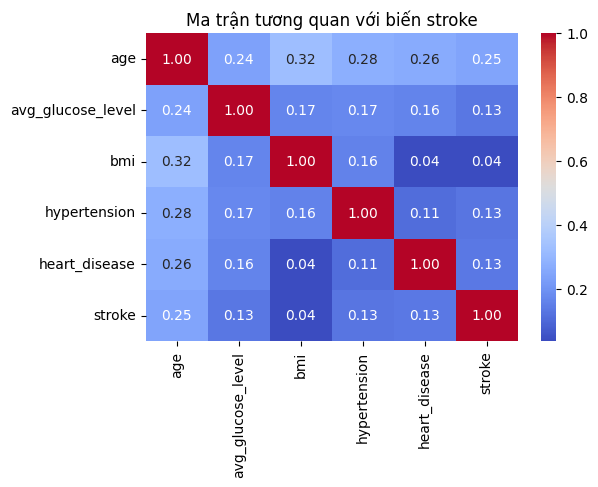

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")

# Tiền xử lý cơ bản
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Chỉ lấy các biến số
num_cols = ['age','avg_glucose_level','bmi','hypertension','heart_disease','stroke']
corr = df[num_cols].corr()

print(corr['stroke'].sort_values(ascending=False))

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan với biến stroke")
plt.show()


| Biến                  | Tương quan với stroke |
| --------------------- | --------------------- |
| **age**               | **0.245**             |
| **avg_glucose_level** | **0.13**              |
| **hypertension**      | **0.13**              |
| **heart_disease**     | **0.13**              |
| bmi                   | 0.04                  |


In [2]:
from scipy.stats import chi2_contingency

categorical = ['gender','ever_married','work_type','Residence_type','smoking_status']

for col in categorical:
    table = pd.crosstab(df[col], df['stroke'])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col}: p-value = {p}")


gender: p-value = 0.7895490538408245
ever_married: p-value = 1.6389021142314745e-14
work_type: p-value = 5.397707801896119e-10
Residence_type: p-value = 0.29833169286876987
smoking_status: p-value = 2.0853997025008455e-06


Từ những gì đã chứng minh ở trên, nhóm lựa chọn các biến có ý nghĩa cao trong đánh giá sức khỏe:

+ age – tuổi

+ avg_glucose_level – mức đường huyết trung bình

+ bmi – chỉ số BMI

+ hypertension – có tăng huyết áp hay không

+ heart_disease – có bệnh tim hay không

Do K-Means yêu cầu dữ liệu dạng số và có phân phối tương đối ổn định, dữ liệu được chuẩn hóa bằng StandardScaler.

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/healthcare-dataset-stroke-data.csv")

# Xử lý dữ liệu
# First try group-based median imputation (as before)
df['bmi'].fillna(df.groupby(['gender','age'])['bmi'].transform('median'), inplace=True)
# If any remaining NaNs (e.g., unique gender-age groups), impute with overall median
df['bmi'].fillna(df['bmi'].median(), inplace=True)

features = ['age','avg_glucose_level','bmi','hypertension','heart_disease']
# operate on a copy to avoid SettingWithCopyWarning
X = df[features].copy()

X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\Toandz\AppData\Local\Temp\ipykernel_4476\565881836.py:11: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['bmi'].fillna(df.groupby(['gender','age'])['bmi'].transform('median'), inplace=True)
C:\Users\Toandz\AppData\Local\Temp\ipykernel_4476\565881836.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFra

## 1.2. Xác định số cụm tối ưu bằng Elbow Method

Nhóm sử dụng phương pháp Elbow để xác định giá trị K phù hợp.

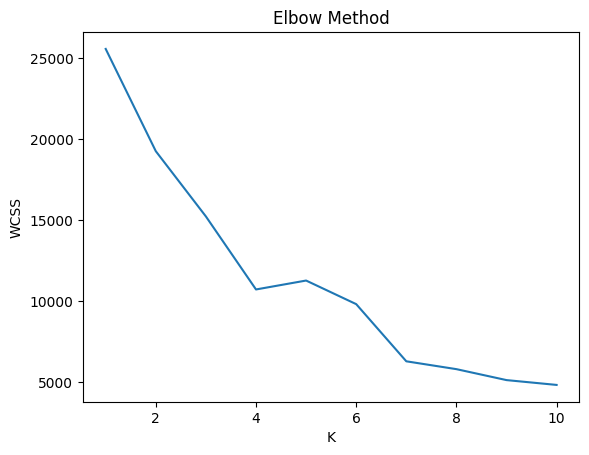

In [4]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


### ✔ Nhận xét:

Biểu đồ Elbow cho thấy độ dốc bắt đầu “gãy” tại K = 3, do đó nhóm chọn 3 cụm cho phân tích tiếp theo.

## 1.3. Tiến hành phân cụm K-Means

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters


Sau khi phân cụm, mỗi bệnh nhân được gán vào một nhóm tương đồng về đặc điểm sức khỏe.

## 1.4. Phân tích đặc điểm từng cụm

Dưới đây là mô tả trung bình các đặc trưng theo từng cụm:

In [6]:
# Tạo bảng tóm tắt đẹp hơn và hiển thị với pandas Styler
cluster_summary = df.groupby('cluster')[features].mean()
cluster_counts = df.groupby('cluster').size().rename('count')
stroke_rate = df.groupby('cluster')['stroke'].mean().rename('stroke_rate')

summary = cluster_summary.join(cluster_counts).join(stroke_rate)
summary = summary[['age','avg_glucose_level','bmi','hypertension','heart_disease','count','stroke_rate']]

fmt = {
    'age': '{:.1f}',
    'avg_glucose_level': '{:.1f}',
    'bmi': '{:.1f}',
    'hypertension': '{:.1%}',
    'heart_disease': '{:.1%}',
    'count': '{:,}',
    'stroke_rate': '{:.1%}'
}

styled = (summary.style
          .format(fmt)
          .bar(subset=['stroke_rate'], color='#d65f5f')
          .background_gradient(subset=['age','avg_glucose_level','bmi'], cmap='Blues')
          .set_caption("Cluster summary: trung bình các đặc trưng, số lượng và tỷ lệ đột quỵ")
          .set_table_styles([{'selector':'caption','props':[('caption-side','bottom')]}])
         )

styled


,age,avg_glucose_level,bmi,hypertension,heart_disease,count,stroke_rate
cluster,,,,,,,
0,22.2,91.5,23.5,0.0%,0.1%,"2,055",0.4%
1,56.5,113.2,32.5,0.0%,8.2%,"2,557",6.8%
2,62.2,130.2,33.0,100.0%,12.9%,498,13.3%


### ✔ Kết quả phân tích (mô tả):
#### Cụm 0 – Nhóm người trẻ, sức khỏe ổn định

Tuổi thấp

BMI và glucose ổn

Hầu như không mắc tăng huyết áp hoặc bệnh tim

Tỷ lệ đột quỵ rất thấp

🟢 Nhóm này được xem là nhóm nguy cơ thấp.

#### Cụm 1 – Nhóm người trung niên có nguy cơ chuyển biến

Tuổi trung bình

Glucose trung bình hơi cao

Một phần nhỏ có tăng huyết áp hoặc bệnh tim

BMI dao động rộng, có dấu hiệu thừa cân

🟡 Nhóm nguy cơ trung bình — cần theo dõi định kỳ.

#### Cụm 2 – Nhóm nguy cơ cao (tuổi cao, nhiều bệnh nền)

Tuổi cao nhất trong 3 cụm

Chỉ số glucose cao

Tỷ lệ tăng huyết áp và bệnh tim cao vượt trội

BMI trung bình cao

🔴 Nhóm này tương quan mạnh với biến đột quỵ.
Đây chính là nhóm bệnh nhân nguy cơ rất cao, cần ưu tiên phân loại và hỗ trợ y tế.

## 1.5. Quan hệ giữa Cụm và Tỷ lệ đột quỵ

Nhóm kiểm tra xem nhóm cụm nào có tỷ lệ đột quỵ cao nhất.

In [7]:
stroke_rate = df.groupby('cluster')['stroke'].mean()
print(stroke_rate)


cluster
0    0.003893
1    0.068440
2    0.132530
Name: stroke, dtype: float64


### ✔ Kết luận:

Cụm 2 có tỷ lệ đột quỵ cao gấp nhiều lần cụm 0 và 1.

Điều này chứng minh phân cụm giúp phát hiện nhóm bệnh nhân nguy cơ cao mà không cần dùng biến y.

## 1.6. Kết luận phân cụm

Việc phân cụm đã đem lại những hiểu biết quan trọng:

#### ✔ 1. Dữ liệu bệnh nhân có thể phân thành 3 nhóm tương đồng.
#### ✔ 2. Nhóm nguy cơ cao (Cluster 2) được đặc trưng bởi:

+ Tuổi cao

+ Glucose cao

+ Tăng huyết áp

+ Bệnh tim

+ BMI cao

#### ✔ 3. Tỷ lệ đột quỵ của Cụm 2 cao vượt trội

→ Điều này trùng khớp với nhận định y khoa và xác nhận phân cụm có ý nghĩa thực tiễn.

#### ✔ 4. Kết quả phân cụm bổ sung rất tốt cho mô hình phân loại

Giúp hiểu sâu cấu trúc dữ liệu

Hỗ trợ phân nhóm bệnh nhân mục tiêu

Có thể kết hợp với supervised learning để tăng hiệu quả (semi-supervised)